In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from surprise import Dataset, Reader
import matplotlib.colors as mcolors

ROOT = Path.cwd().resolve()
if (ROOT / 'src').exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / 'src').exists():
    sys.path.insert(0, str(ROOT.parent))

from cluster_simulation import generate_simulation, plot_simulation_distributions_and_heatmap, plot_cluster_ordered_heatmap

from src.utils.popularity import run_topk_loop_with_state, popularity_analysis
from src.features.affinity import affinity_matrix, plot_affinity_heatmap
from src.eval.simulation_metrics import evaluate_run_topk_new_ratings, evaluate_run_awpd_observations

Cargar simulación como train

In [ ]:
ic = 10
uc = 10
params = dict(
    U=3000,
    I=1682,
    density=0.003,
    alpha_user=0,
    alpha_item=0,
    seed=42,
    min_user_ratings=None,
    min_item_ratings=None,
    n_user_clusters=uc,
    n_item_clusters=ic,
    affinity = affinity_matrix(uc, ic, seed=42, kind="outliers"),
    beta=1.7,
    tau=np.array([-1.2, -0.4, 0.4, 1.2]),
    mu=0,
    sigma_bu=0.5,
    sigma_bi=0.5,
    sigma_eps=0.45,
    gamma=0.5,
)

U, I = params["U"], params["I"]

R_syn, state = generate_simulation(return_state=True, **params)
uc = state["user_cluster"]
ic = state["item_cluster"]
A = state["A"]

ratings_long = pd.DataFrame(R_syn).stack().reset_index()
ratings_long.columns = ["UserID", "MovieID", "Rating"]
reader = Reader(rating_scale=(1, 5))
data_train = Dataset.load_from_df(ratings_long[["UserID", "MovieID", "Rating"]], reader)


Density: 0.011890606420927468


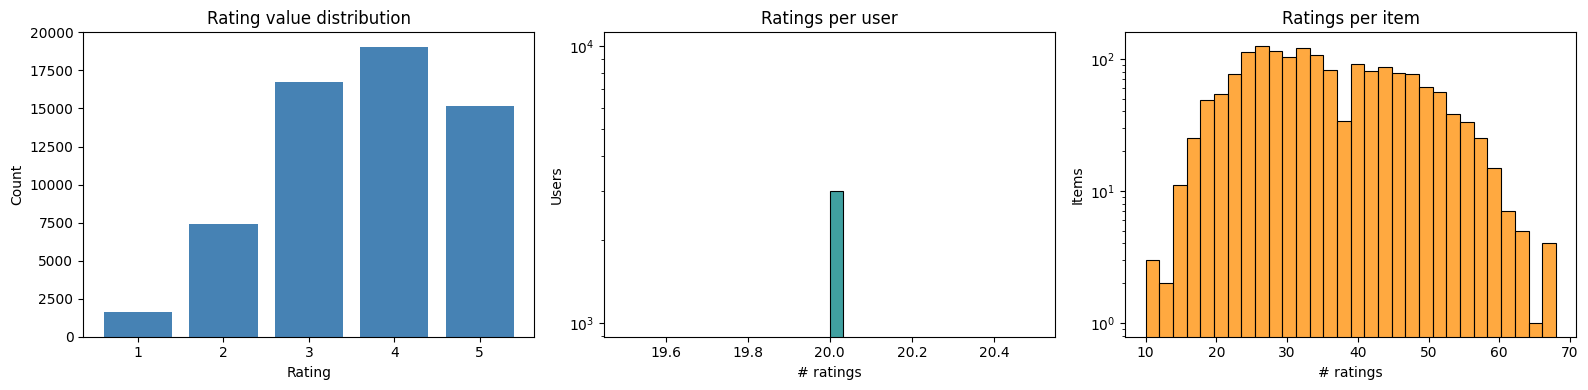

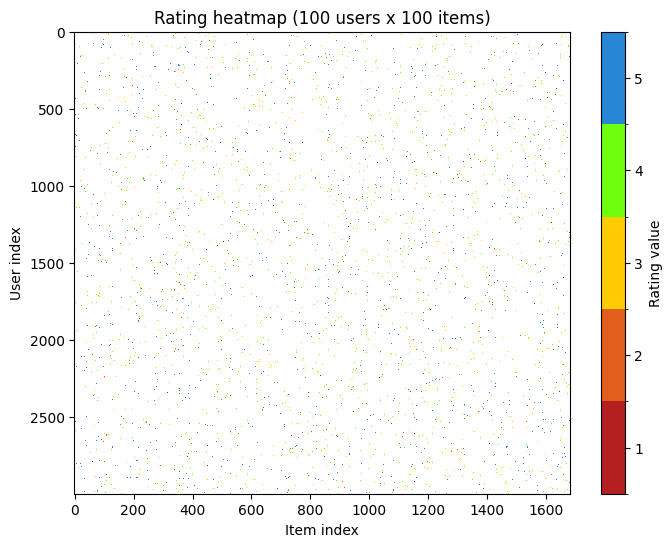

(<Figure size 1600x400 with 3 Axes>, <Figure size 800x600 with 2 Axes>)

In [ ]:
plot_simulation_distributions_and_heatmap(R_syn)

In [ ]:
ratings_by_model, topk_by_model, data_train_by_model, predictions_by_model = run_topk_loop_with_state(
    ratings_long=ratings_long,
    reader=reader,
    U=U,
    I=I,
    uc=state["user_cluster"],
    ic=state["item_cluster"],
    state=state,
    A=state.get("A"),
    n_runs=40,
    k=5,
    cooldown_runs=5,
    include_base_in_cooldown=True,
    return_predictions=True,
)



## Guardar artefactos para análisis posterior

In [ ]:
import pickle
from pathlib import Path

ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)

# ratings_long: train set original
ratings_long.to_parquet(ARTIFACTS / "ratings_long.parquet", index=False)

# ratings_by_model: dict[str, list[pd.DataFrame]] — cumulative per run
with open(ARTIFACTS / "ratings_by_model.pkl", "wb") as f:
    pickle.dump(ratings_by_model, f)

# simulation state needed for awpd
import numpy as np
np.savez(
    ARTIFACTS / "simulation_state.npz",
    user_clusters=uc,
    item_clusters=ic,
    affinity=A,
    popularity=state["pi"],
    num_users=np.array([U]),
)

print("Artefactos guardados en", ARTIFACTS.resolve())


Artefactos guardados en C:\Users\mrari\OneDrive\Desktop\TFG\Sistemas de recomendación\artifacts


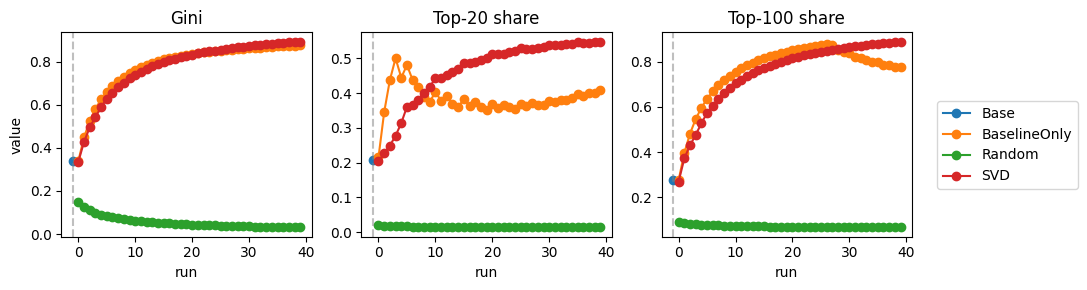

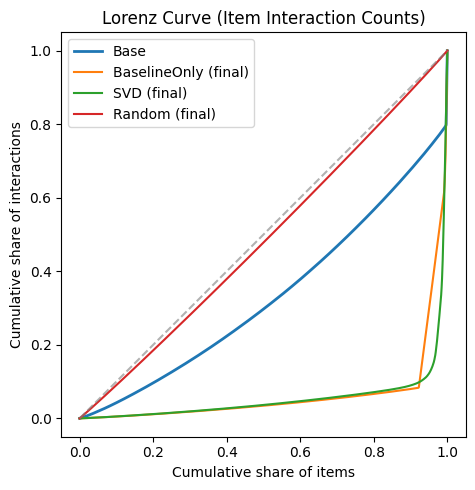

In [ ]:
popularity_metrics = popularity_analysis(ratings_by_model)



Density: 0.12409294490685692


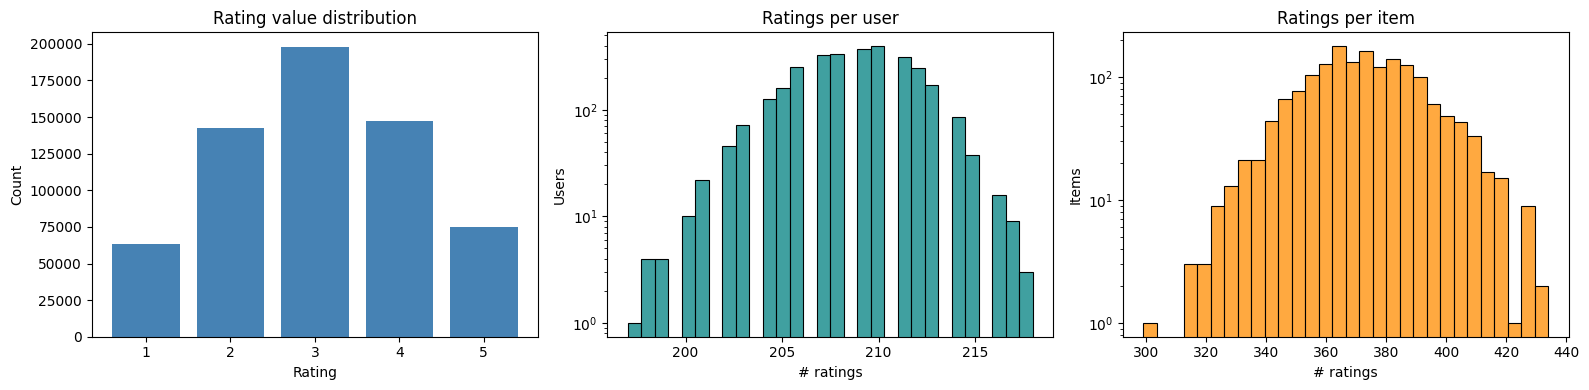

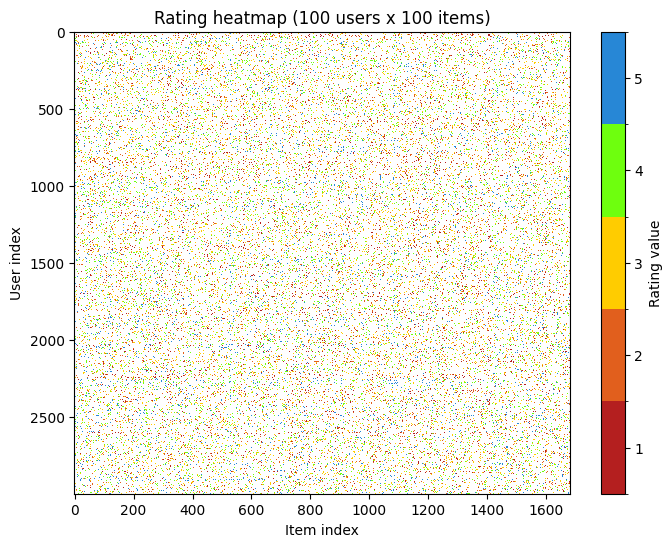

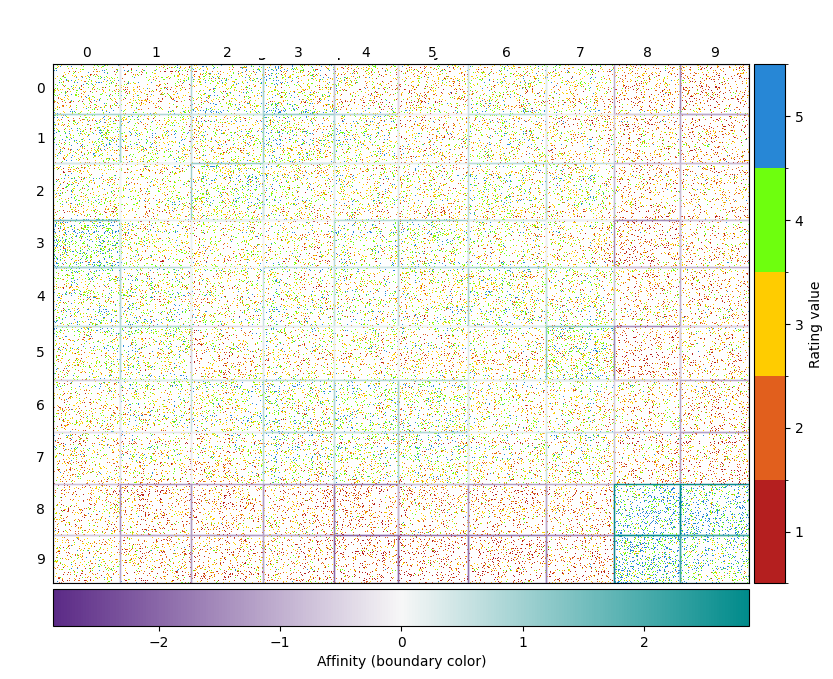

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [ ]:
ratings_matrix = ratings_by_model["Random"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)

Density: 0.08835850178359096


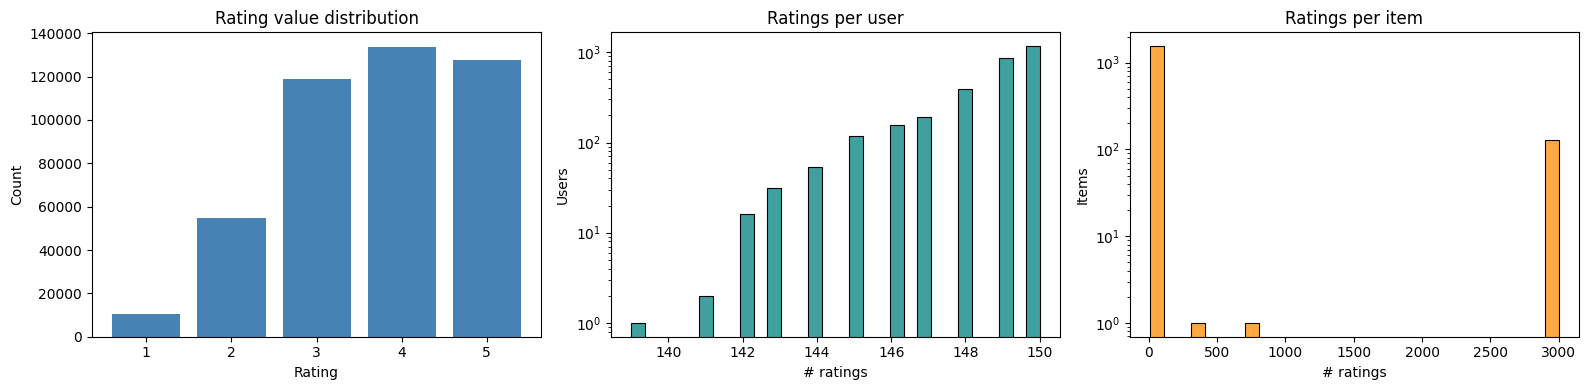

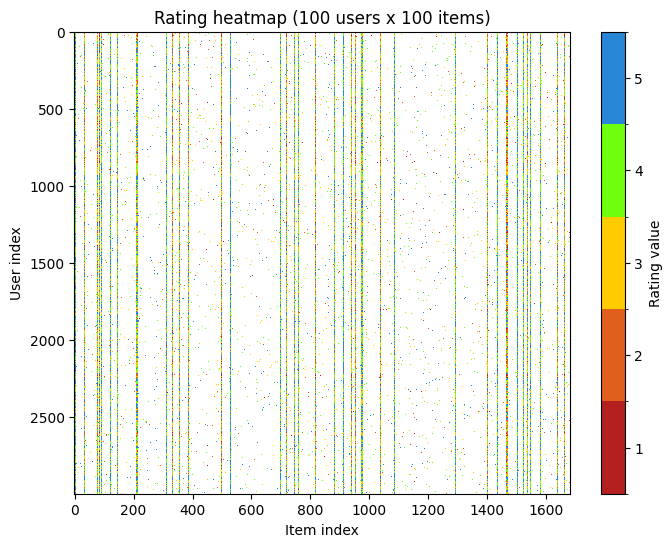

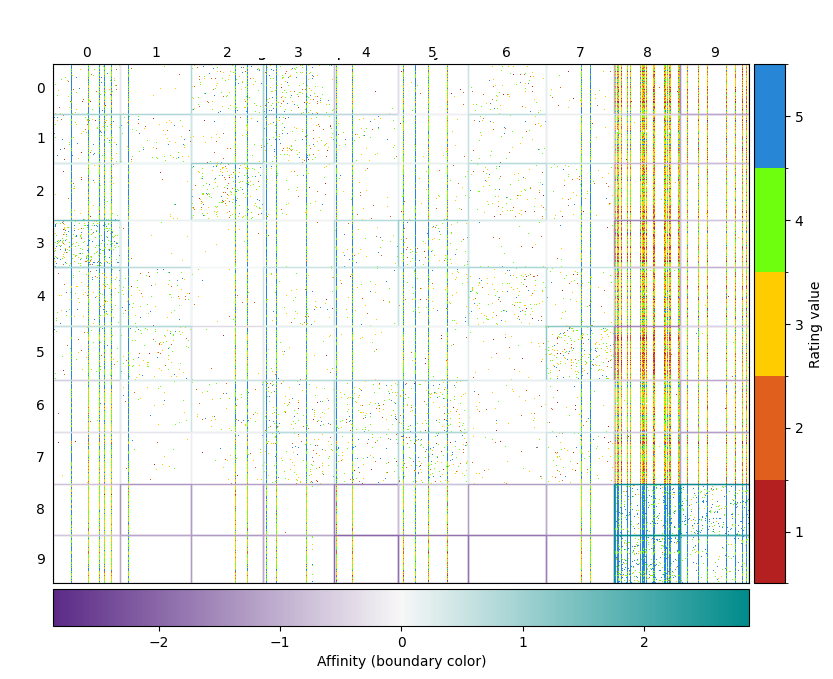

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [ ]:
ratings_matrix = ratings_by_model["BaselineOnly"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)

Density: 0.03453289734443123


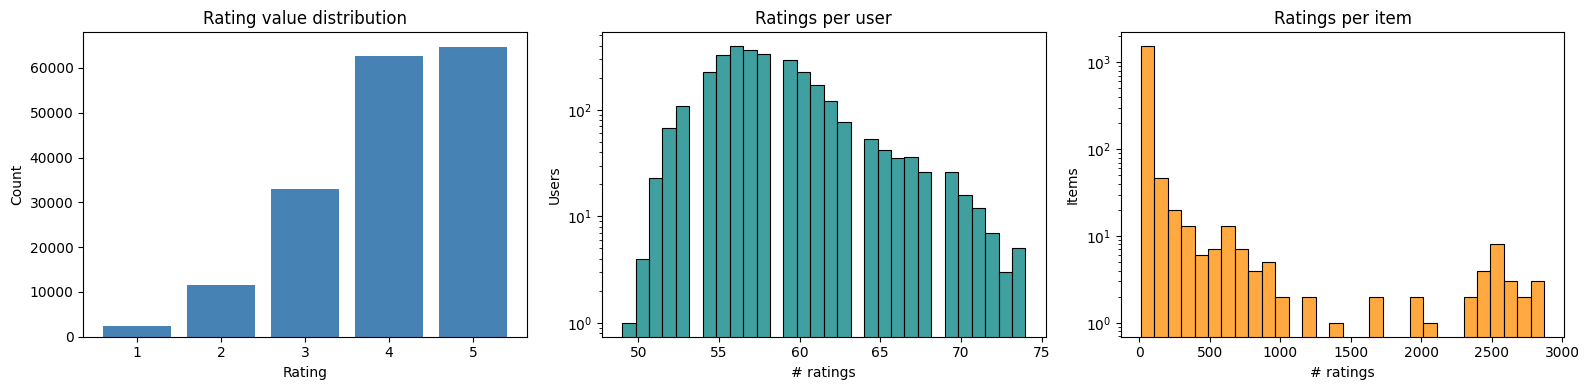

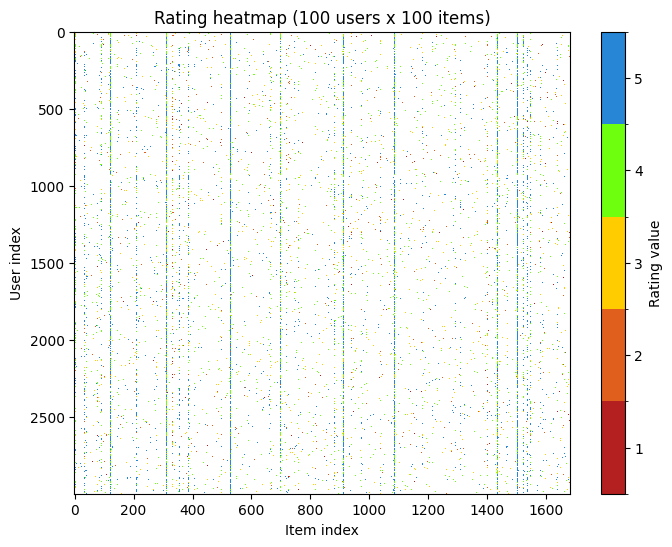

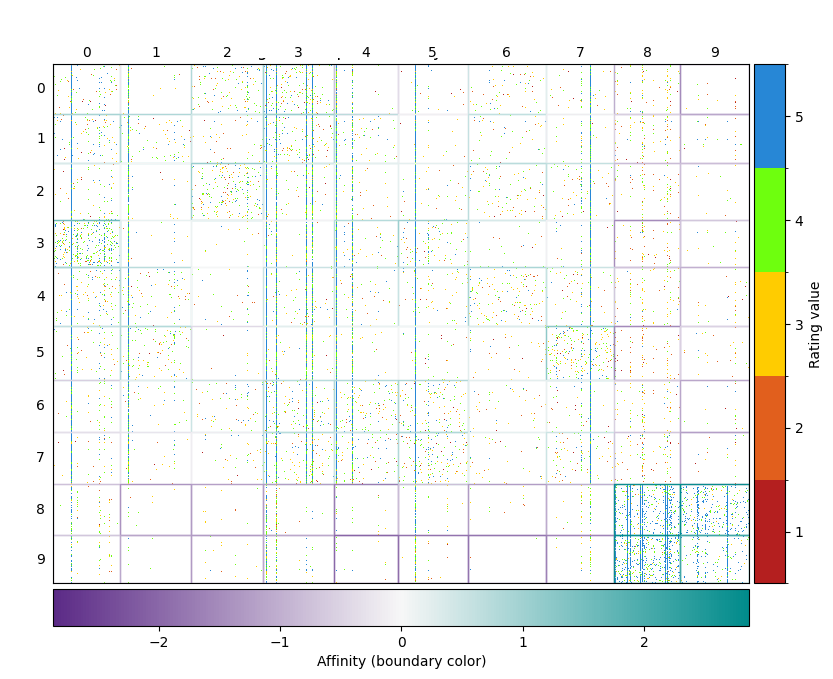

(<Figure size 1000x800 with 9 Axes>,
 array([   0,    7,   10, ..., 2967, 2983, 2999], dtype=int64),
 array([   3,   56,   65, ..., 1668, 1670, 1672], dtype=int64))

In [ ]:
ratings_matrix = ratings_by_model["SVD"][-1].pivot_table(index='UserID', columns='MovieID', values='Rating')
plot_simulation_distributions_and_heatmap(ratings_matrix)
plot_cluster_ordered_heatmap(ratings_matrix, uc, ic, A)